## Variant 6:
$$\mathbf{x}_{\mu} = [7, 2, 4, 3, 4, 5, 0, 0, 0, 0]^\mathrm{T}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import ifft

## Helper function

In [2]:
def idft_synthesis(X_mu, label=''):
    """Synthesize a signal via IDFT in matrix notation and display W, K."""
    N = len(X_mu)
    k = np.arange(N)
    mu = np.arange(N)

    # --- build matrices ---
    K = np.outer(k, mu)           # N×N matrix of all k·μ products
    W = np.exp(+1j * 2*np.pi/N * K)  # Fourier matrix

    # --- IDFT (matrix multiplication) ---
    x_k = (1/N) * W @ X_mu

    # --- print matrices ---
    print(f'\n=== N = {N} {label} ===')
    print(f'\nMatrix K ({N}×{N}):')
    print(K)
    print(f'\nFourier matrix W ({N}×{N}) [rounded to 3 decimals]:')
    print(np.round(W, 3))

    # --- verify against numpy ifft ---
    ok = np.allclose(x_k, ifft(X_mu))
    print(f'\nMatches numpy.ifft: {ok}')

    return k, x_k, W, K

## Case 1 – N = 10 (original spectrum)

The spectrum vector from the assignment:
$$\mathbf{x}_{\mu} = [7, 2, 4, 3, 4, 5, 0, 0, 0, 0]^\mathrm{T}, \quad N=10$$

In [3]:
X_mu_orig = np.array([7, 2, 4, 3, 4, 5, 0, 0, 0, 0], dtype=complex)

k10, x10, W10, K10 = idft_synthesis(X_mu_orig)


=== N = 10  ===

Matrix K (10×10):
[[ 0  0  0  0  0  0  0  0  0  0]
 [ 0  1  2  3  4  5  6  7  8  9]
 [ 0  2  4  6  8 10 12 14 16 18]
 [ 0  3  6  9 12 15 18 21 24 27]
 [ 0  4  8 12 16 20 24 28 32 36]
 [ 0  5 10 15 20 25 30 35 40 45]
 [ 0  6 12 18 24 30 36 42 48 54]
 [ 0  7 14 21 28 35 42 49 56 63]
 [ 0  8 16 24 32 40 48 56 64 72]
 [ 0  9 18 27 36 45 54 63 72 81]]

Fourier matrix W (10×10) [rounded to 3 decimals]:
[[ 1.   +0.j     1.   +0.j     1.   +0.j     1.   +0.j     1.   +0.j
   1.   +0.j     1.   +0.j     1.   +0.j     1.   +0.j     1.   +0.j   ]
 [ 1.   +0.j     0.809+0.588j  0.309+0.951j -0.309+0.951j -0.809+0.588j
  -1.   +0.j    -0.809-0.588j -0.309-0.951j  0.309-0.951j  0.809-0.588j]
 [ 1.   +0.j     0.309+0.951j -0.809+0.588j -0.809-0.588j  0.309-0.951j
   1.   -0.j     0.309+0.951j -0.809+0.588j -0.809-0.588j  0.309-0.951j]
 [ 1.   +0.j    -0.309+0.951j -0.809-0.588j  0.809-0.588j  0.309+0.951j
  -1.   +0.j     0.309-0.951j  0.809+0.588j -0.809+0.588j -0.309-0.951j]
 [ 1.

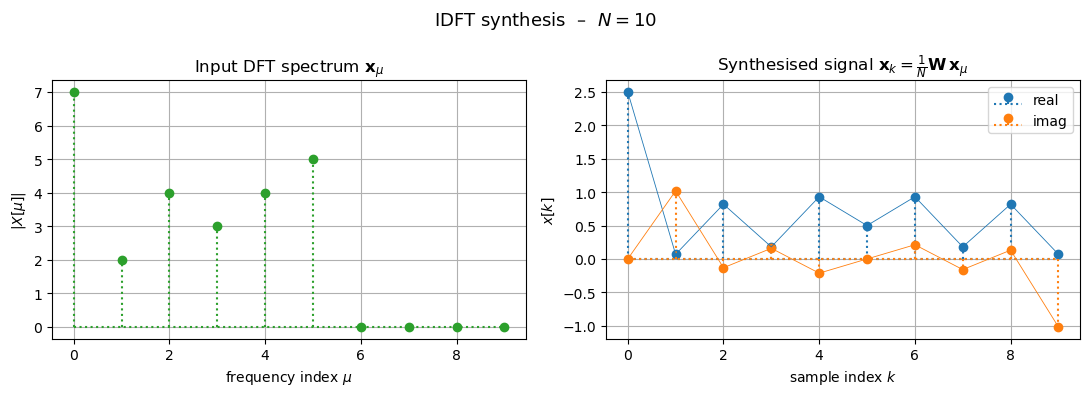

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle(r'IDFT synthesis  –  $N=10$', fontsize=13)

# spectrum
ax = axes[0]
ax.stem(k10, np.abs(X_mu_orig), markerfmt='C2o', linefmt='C2:', basefmt='C2:')
ax.set_xlabel(r'frequency index $\mu$')
ax.set_ylabel(r'$|X[\mu]|$')
ax.set_title(r'Input DFT spectrum $\mathbf{x}_{\mu}$')
ax.grid(True)

# synthesised signal
ax = axes[1]
ax.stem(k10, np.real(x10), markerfmt='C0o', linefmt='C0:', basefmt='C0:', label='real')
ax.stem(k10, np.imag(x10), markerfmt='C1o', linefmt='C1:', basefmt='C1:', label='imag')
ax.plot(k10, np.real(x10), 'C0-', lw=0.6)
ax.plot(k10, np.imag(x10), 'C1-', lw=0.6)
ax.set_xlabel(r'sample index $k$')
ax.set_ylabel(r'$x[k]$')
ax.set_title(r'Synthesised signal $\mathbf{x}_k = \frac{1}{N}\mathbf{W}\,\mathbf{x}_{\mu}$')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

## Case 2 – N = 5 (first half of spectrum, shorter block)

Keep only the first 5 DFT coefficients to examine the effect of a smaller block length:
$$\mathbf{x}_{\mu}^{(5)} = [7, 2, 4, 3, 4]^\mathrm{T}, \quad N=5$$

In [5]:
X_mu_5 = X_mu_orig[:5].copy()

k5, x5, W5, K5 = idft_synthesis(X_mu_5, label='(first 5 coefficients)')


=== N = 5 (first 5 coefficients) ===

Matrix K (5×5):
[[ 0  0  0  0  0]
 [ 0  1  2  3  4]
 [ 0  2  4  6  8]
 [ 0  3  6  9 12]
 [ 0  4  8 12 16]]

Fourier matrix W (5×5) [rounded to 3 decimals]:
[[ 1.   +0.j     1.   +0.j     1.   +0.j     1.   +0.j     1.   +0.j   ]
 [ 1.   +0.j     0.309+0.951j -0.809+0.588j -0.809-0.588j  0.309-0.951j]
 [ 1.   +0.j    -0.809+0.588j  0.309-0.951j  0.309+0.951j -0.809-0.588j]
 [ 1.   +0.j    -0.809-0.588j  0.309+0.951j  0.309-0.951j -0.809+0.588j]
 [ 1.   +0.j     0.309-0.951j -0.809-0.588j -0.809+0.588j  0.309+0.951j]]

Matches numpy.ifft: True


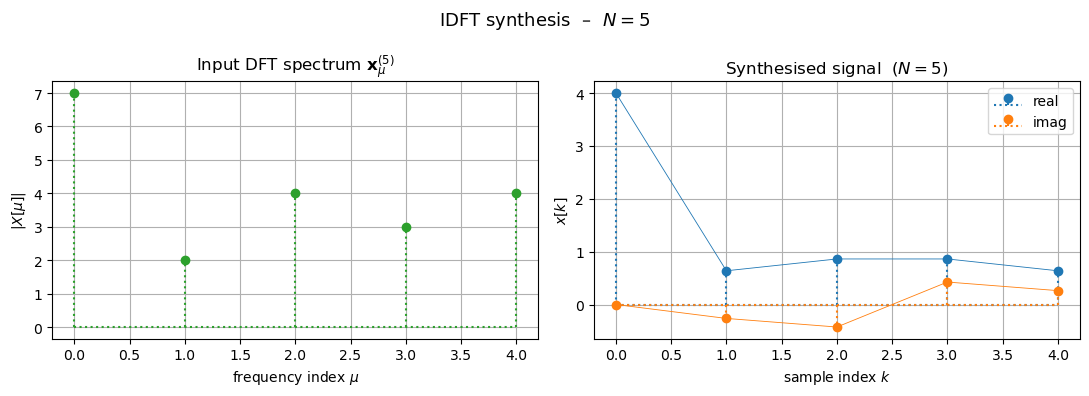

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle(r'IDFT synthesis  –  $N=5$', fontsize=13)

ax = axes[0]
ax.stem(k5, np.abs(X_mu_5), markerfmt='C2o', linefmt='C2:', basefmt='C2:')
ax.set_xlabel(r'frequency index $\mu$')
ax.set_ylabel(r'$|X[\mu]|$')
ax.set_title(r'Input DFT spectrum $\mathbf{x}_{\mu}^{(5)}$')
ax.grid(True)

ax = axes[1]
ax.stem(k5, np.real(x5), markerfmt='C0o', linefmt='C0:', basefmt='C0:', label='real')
ax.stem(k5, np.imag(x5), markerfmt='C1o', linefmt='C1:', basefmt='C1:', label='imag')
ax.plot(k5, np.real(x5), 'C0-', lw=0.6)
ax.plot(k5, np.imag(x5), 'C1-', lw=0.6)
ax.set_xlabel(r'sample index $k$')
ax.set_ylabel(r'$x[k]$')
ax.set_title(r'Synthesised signal  ($N=5$)')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

## Case 3 – N = 20 (zero-padded spectrum)

Zero-pad the original spectrum to $N=20$, which effectively increases the frequency resolution of the analysis:
$$\mathbf{x}_{\mu}^{(20)} = [7, 2, 4, 3, 4, 5, 0, \dots, 0]^\mathrm{T}, \quad N=20$$

In [7]:
X_mu_20 = np.zeros(20, dtype=complex)
X_mu_20[:10] = X_mu_orig

k20, x20, W20, K20 = idft_synthesis(X_mu_20, label='(zero-padded to N=20)')


=== N = 20 (zero-padded to N=20) ===

Matrix K (20×20):
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
   18  19]
 [  0   2   4   6   8  10  12  14  16  18  20  22  24  26  28  30  32  34
   36  38]
 [  0   3   6   9  12  15  18  21  24  27  30  33  36  39  42  45  48  51
   54  57]
 [  0   4   8  12  16  20  24  28  32  36  40  44  48  52  56  60  64  68
   72  76]
 [  0   5  10  15  20  25  30  35  40  45  50  55  60  65  70  75  80  85
   90  95]
 [  0   6  12  18  24  30  36  42  48  54  60  66  72  78  84  90  96 102
  108 114]
 [  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
  126 133]
 [  0   8  16  24  32  40  48  56  64  72  80  88  96 104 112 120 128 136
  144 152]
 [  0   9  18  27  36  45  54  63  72  81  90  99 108 117 126 135 144 153
  162 171]
 [  0  10  20  30  40  50  60  70  80  90 100 110 120 130 140 150 160 170
  180 190]
 [  0  1

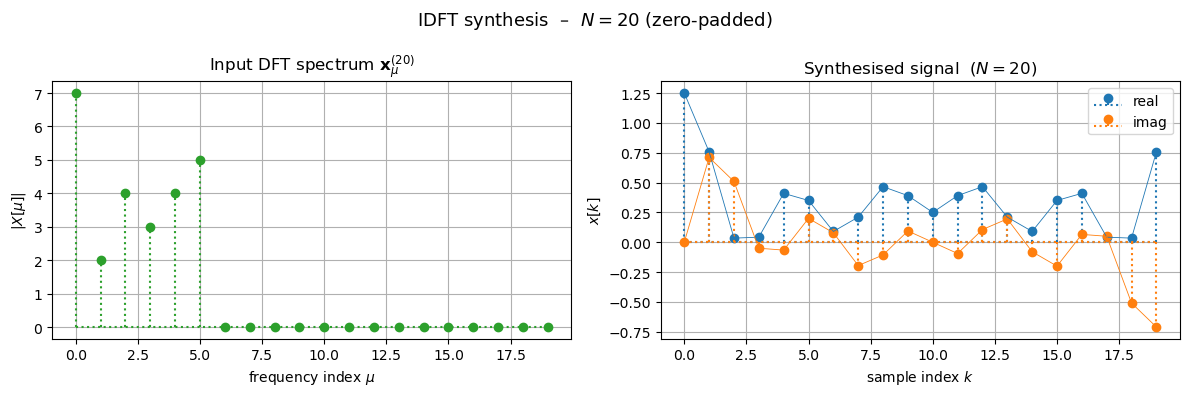

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(r'IDFT synthesis  –  $N=20$ (zero-padded)', fontsize=13)

ax = axes[0]
ax.stem(np.arange(20), np.abs(X_mu_20), markerfmt='C2o', linefmt='C2:', basefmt='C2:')
ax.set_xlabel(r'frequency index $\mu$')
ax.set_ylabel(r'$|X[\mu]|$')
ax.set_title(r'Input DFT spectrum $\mathbf{x}_{\mu}^{(20)}$')
ax.grid(True)

ax = axes[1]
ax.stem(k20, np.real(x20), markerfmt='C0o', linefmt='C0:', basefmt='C0:', label='real')
ax.stem(k20, np.imag(x20), markerfmt='C1o', linefmt='C1:', basefmt='C1:', label='imag')
ax.plot(k20, np.real(x20), 'C0-', lw=0.6)
ax.plot(k20, np.imag(x20), 'C1-', lw=0.6)
ax.set_xlabel(r'sample index $k$')
ax.set_ylabel(r'$x[k]$')
ax.set_title(r'Synthesised signal  ($N=20$)')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

## Summary – all three signals overlaid


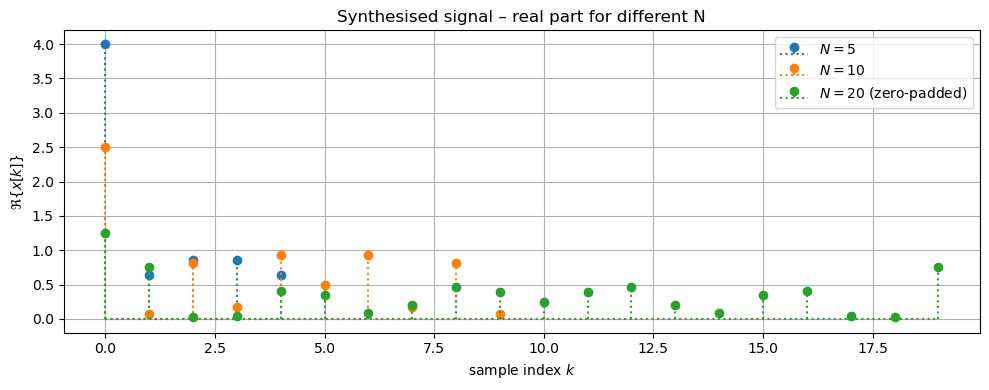

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.stem(k5,  np.real(x5),  markerfmt='C0o', linefmt='C0:', basefmt='C0:', label=r'$N=5$')
ax.stem(k10, np.real(x10), markerfmt='C1o', linefmt='C1:', basefmt='C1:', label=r'$N=10$')
ax.stem(k20, np.real(x20), markerfmt='C2o', linefmt='C2:', basefmt='C2:', label=r'$N=20$ (zero-padded)')

ax.set_xlabel(r'sample index $k$')
ax.set_ylabel(r'$\Re\{x[k]\}$')
ax.set_title('Synthesised signal – real part for different N')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()